IID

In [2]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
CLIENT_FOLDER = "../data/clients_iid"
# CLIENT_FOLDER = "../data/clients_noniid"

NUM_CLIENTS = 10
LOCAL_EPOCHS = 3
ROUNDS = 70
BATCH_SIZE = 256
LR = 0.0007

CLIP_NORM = 1.0
NOISE_MULTIPLIER = 0.5

In [4]:
import pandas as pd

X_train_full = pd.read_csv("../data/X_train_enc.csv")
X_test = pd.read_csv("../data/X_test_enc.csv")
y_test = pd.read_csv("../data/y_test.csv")["label"].values

print("Train shape:", X_train_full.shape)
print("Test shape:", X_test.shape)

Train shape: (175341, 196)
Test shape: (82332, 196)


In [5]:
from sklearn.preprocessing import StandardScaler
import torch

scaler = StandardScaler()
scaler.fit(X_train_full)

X_test_scaled = scaler.transform(X_test)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

In [6]:
import torch.nn as nn

class IDSNet(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader

def load_client_data(client_id, client_folder, scaler, batch_size):

    X_client = pd.read_csv(f"{client_folder}/client_{client_id}_X.csv")
    y_client = pd.read_csv(f"{client_folder}/client_{client_id}_y.csv")["label"].values

    X_scaled = scaler.transform(X_client)

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_client.reshape(-1,1), dtype=torch.float32)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    return loader, len(X_client)

Local client training with DP

In [8]:
import copy
import torch
import torch.nn as nn

def train_local_model_dp(global_model, client_loader, local_epochs, lr):

    local_model = copy.deepcopy(global_model)
    local_model.train()

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(local_model.parameters(), lr=lr)

    for epoch in range(local_epochs):

        for xb, yb in client_loader:

            optimizer.zero_grad()

            logits = local_model(xb)
            loss = criterion(logits, yb)

            loss.backward()

            # Clip gradients
            torch.nn.utils.clip_grad_norm_(local_model.parameters(), CLIP_NORM)

            # Add Gaussian noise
            for param in local_model.parameters():
                if param.grad is not None:
                    noise = torch.normal(
                        mean=0,
                        std=NOISE_MULTIPLIER * CLIP_NORM,
                        size=param.grad.shape
                    )
                    param.grad += noise

            optimizer.step()

    return local_model.state_dict()

In [9]:
import copy

def fedavg(client_state_dicts, client_sizes):

    total_size = sum(client_sizes)

    avg_state = copy.deepcopy(client_state_dicts[0])

    for key in avg_state.keys():
        avg_state[key] = client_state_dicts[0][key] * (client_sizes[0]/total_size)

    for i in range(1, len(client_state_dicts)):
        for key in avg_state.keys():
            avg_state[key] += client_state_dicts[i][key] * (client_sizes[i]/total_size)

    return avg_state

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import torch

def evaluate_model(model, X_test_tensor, y_test):

    model.eval()

    with torch.no_grad():

        logits = model(X_test_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        preds = (probs >= 0.5).astype(int)

    results = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs)
    }

    return results, preds, probs

In [11]:
input_dim = X_train_full.shape[1]

global_model = IDSNet(input_dim)

print("DP Federated model initialized.")

DP Federated model initialized.


Federataed Trainig with DP

In [12]:
history = []

for rnd in range(ROUNDS):

    print(f"\n--- Round {rnd+1}/{ROUNDS} ---")

    client_states = []
    client_sizes = []

    for client_id in range(NUM_CLIENTS):

        loader, size = load_client_data(
            client_id,
            CLIENT_FOLDER,
            scaler,
            BATCH_SIZE
        )

        local_state = train_local_model_dp(
            global_model,
            loader,
            LOCAL_EPOCHS,
            LR
        )

        client_states.append(local_state)
        client_sizes.append(size)

        print(f"Client {client_id} trained on {size} samples")

    new_global = fedavg(client_states, client_sizes)
    global_model.load_state_dict(new_global)

    results, _, _ = evaluate_model(global_model, X_test_tensor, y_test)

    results["round"] = rnd + 1
    history.append(results)

    print(results)


--- Round 1/70 ---
Client 0 trained on 17535 samples
Client 1 trained on 17534 samples
Client 2 trained on 17534 samples
Client 3 trained on 17534 samples
Client 4 trained on 17534 samples
Client 5 trained on 17534 samples
Client 6 trained on 17534 samples
Client 7 trained on 17534 samples
Client 8 trained on 17534 samples
Client 9 trained on 17534 samples
{'accuracy': 0.5506000097167566, 'precision': 0.5506000097167566, 'recall': 1.0, 'f1': 0.710176713873919, 'roc_auc': np.float64(0.7133811638339125), 'round': 1}

--- Round 2/70 ---
Client 0 trained on 17535 samples
Client 1 trained on 17534 samples
Client 2 trained on 17534 samples
Client 3 trained on 17534 samples
Client 4 trained on 17534 samples
Client 5 trained on 17534 samples
Client 6 trained on 17534 samples
Client 7 trained on 17534 samples
Client 8 trained on 17534 samples
Client 9 trained on 17534 samples
{'accuracy': 0.5506000097167566, 'precision': 0.5506000097167566, 'recall': 1.0, 'f1': 0.710176713873919, 'roc_auc': np

In [13]:
import pandas as pd

history_df = pd.DataFrame(history)

print(history_df)

    accuracy  precision    recall        f1   roc_auc  round
0   0.550600   0.550600  1.000000  0.710177  0.713381      1
1   0.550600   0.550600  1.000000  0.710177  0.777452      2
2   0.550600   0.550600  1.000000  0.710177  0.808474      3
3   0.550600   0.550600  1.000000  0.710177  0.824023      4
4   0.550600   0.550600  1.000000  0.710177  0.837767      5
..       ...        ...       ...       ...       ...    ...
65  0.820228   0.760935  0.982022  0.857457  0.955030     66
66  0.820106   0.760894  0.981801  0.857346  0.955294     67
67  0.820774   0.761799  0.981338  0.857743  0.956222     68
68  0.820787   0.762315  0.980102  0.857598  0.956132     69
69  0.820313   0.761241  0.981492  0.857448  0.956565     70

[70 rows x 6 columns]


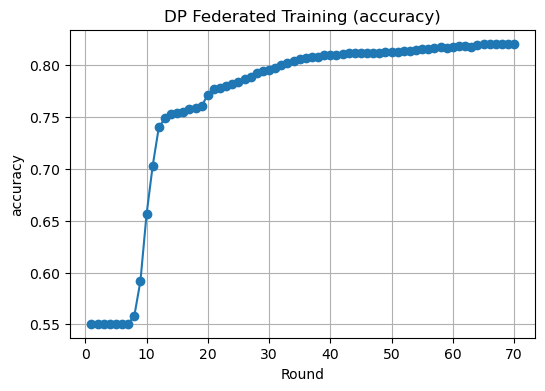

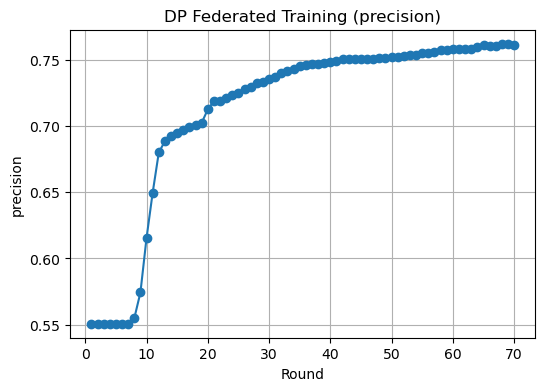

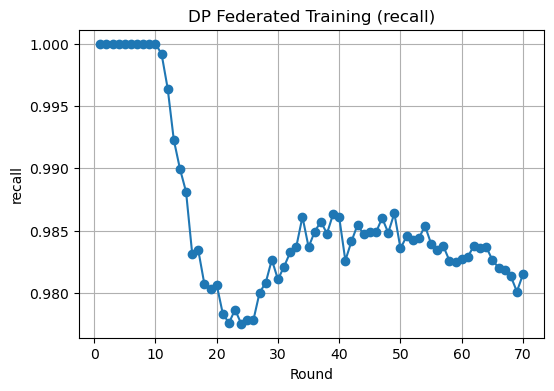

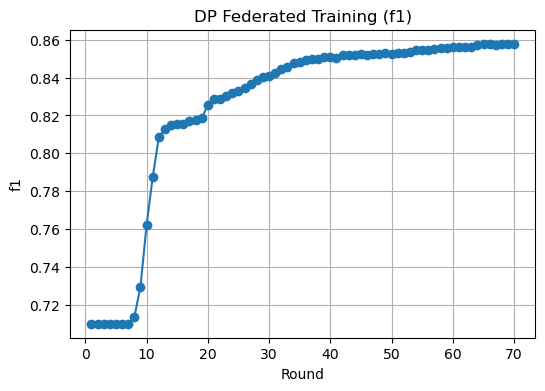

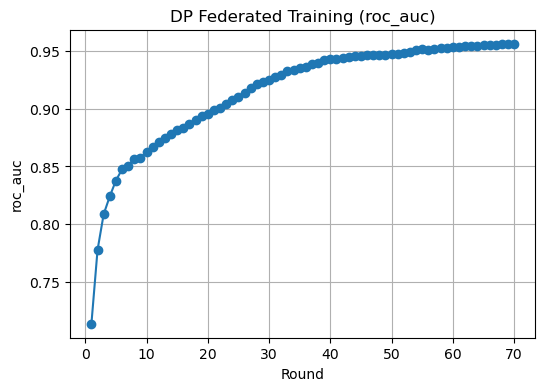

In [14]:
import matplotlib.pyplot as plt

metrics = ["accuracy","precision","recall","f1","roc_auc"]

for m in metrics:

    plt.figure(figsize=(6,4))
    plt.plot(history_df["round"], history_df[m], marker="o")
    plt.title(f"DP Federated Training ({m})")
    plt.xlabel("Round")
    plt.ylabel(m)
    plt.grid(True)
    plt.show()

In [15]:
final_results, final_pred, final_prob = evaluate_model(global_model, X_test_tensor, y_test)
import pandas as pd

pd.DataFrame({
    "y_true": y_test,
    "y_prob": final_prob,
    "y_pred": final_pred
}).to_csv("../results/fl_dp_iid_predictions.csv", index=False)

print("Saved: ../results/fl_dp_iid_predictions.csv")
print("Final DP Results")
print(final_results)

Saved: ../results/fl_dp_iid_predictions.csv
Final DP Results
{'accuracy': 0.8203128795608026, 'precision': 0.761240761018341, 'recall': 0.9814921027089032, 'f1': 0.8574484486413567, 'roc_auc': np.float64(0.9565649350378349)}


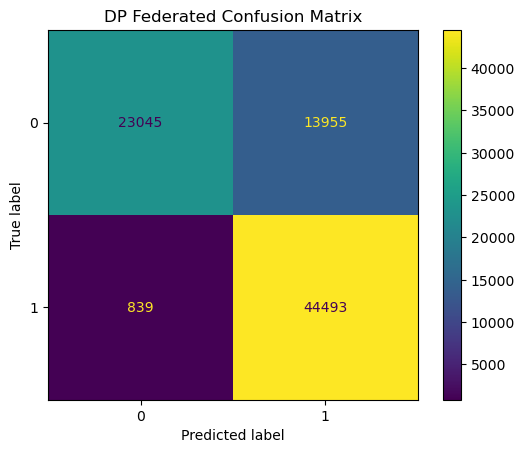

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("DP Federated Confusion Matrix")
plt.show()

In [17]:
import os
import pandas as pd

os.makedirs("../results", exist_ok=True)

history_df.to_csv("../results/fl_dp_rounds.csv", index=False)

final_df = pd.DataFrame([{
    "model": "FederatedNN_DP",
    **final_results
}])

final_df.to_csv("../results/fl_dp_final.csv", index=False)

print("Results saved.")

Results saved.


Non-IID

In [33]:
CLIENT_FOLDER = "../data/clients_noniid"

NUM_CLIENTS = 10
LOCAL_EPOCHS = 3
ROUNDS = 70
BATCH_SIZE = 256
LR = 0.0007

CLIP_NORM = 1.0
NOISE_MULTIPLIER = 0.5

In [19]:
X_train_full = pd.read_csv("../data/X_train_enc.csv")
X_test = pd.read_csv("../data/X_test_enc.csv")
y_test = pd.read_csv("../data/y_test.csv")["label"].values

print("Train shape:", X_train_full.shape)
print("Test shape:", X_test.shape)

Train shape: (175341, 196)
Test shape: (82332, 196)


In [20]:
scaler = StandardScaler()
scaler.fit(X_train_full)

X_test_scaled = scaler.transform(X_test)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

In [21]:
class IDSNet(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [22]:
def load_client_data(client_id, client_folder, scaler, batch_size):

    X_client = pd.read_csv(f"{client_folder}/client_{client_id}_X.csv")
    y_client = pd.read_csv(f"{client_folder}/client_{client_id}_y.csv")["label"].values

    X_scaled = scaler.transform(X_client)

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_client.reshape(-1, 1), dtype=torch.float32)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    return loader, len(X_client)

In [23]:
def train_local_model_dp(global_model, client_loader, local_epochs, lr):

    local_model = copy.deepcopy(global_model)
    local_model.train()

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(local_model.parameters(), lr=lr)

    for epoch in range(local_epochs):

        for xb, yb in client_loader:

            optimizer.zero_grad()

            logits = local_model(xb)
            loss = criterion(logits, yb)

            loss.backward()

            # Clip gradients
            torch.nn.utils.clip_grad_norm_(local_model.parameters(), CLIP_NORM)

            # Add Gaussian noise
            for param in local_model.parameters():
                if param.grad is not None:
                    noise = torch.normal(
                        mean=0,
                        std=NOISE_MULTIPLIER * CLIP_NORM,
                        size=param.grad.shape,
                        device=param.grad.device
                    )
                    param.grad += noise

            optimizer.step()

    return local_model.state_dict()

In [24]:
import copy

def fedavg(client_state_dicts, client_sizes):

    total_size = sum(client_sizes)

    avg_state = copy.deepcopy(client_state_dicts[0])

    for key in avg_state.keys():
        avg_state[key] = client_state_dicts[0][key] * (client_sizes[0] / total_size)

    for i in range(1, len(client_state_dicts)):
        for key in avg_state.keys():
            avg_state[key] += client_state_dicts[i][key] * (client_sizes[i] / total_size)

    return avg_state

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import torch

def evaluate_model(model, X_test_tensor, y_test):

    model.eval()

    with torch.no_grad():

        logits = model(X_test_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        preds = (probs >= 0.5).astype(int)

    results = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probs)
    }

    return results, preds, probs

In [26]:
input_dim = X_train_full.shape[1]

global_model = IDSNet(input_dim)

print("DP Federated non-IID model initialized.")

DP Federated non-IID model initialized.


In [27]:
history = []

for rnd in range(ROUNDS):

    print(f"\n--- Non-IID DP Round {rnd+1}/{ROUNDS} ---")

    client_states = []
    client_sizes = []

    for client_id in range(NUM_CLIENTS):

        loader, size = load_client_data(
            client_id,
            CLIENT_FOLDER,
            scaler,
            BATCH_SIZE
        )

        local_state = train_local_model_dp(
            global_model,
            loader,
            LOCAL_EPOCHS,
            LR
        )

        client_states.append(local_state)
        client_sizes.append(size)

        print(f"Client {client_id} trained on {size} samples")

    new_global = fedavg(client_states, client_sizes)
    global_model.load_state_dict(new_global)

    results, _, _ = evaluate_model(global_model, X_test_tensor, y_test)

    results["round"] = rnd + 1
    history.append(results)

    print(results)


--- Non-IID DP Round 1/70 ---
Client 0 trained on 17534 samples
Client 1 trained on 17534 samples
Client 2 trained on 17534 samples
Client 3 trained on 17534 samples
Client 4 trained on 17534 samples
Client 5 trained on 17534 samples
Client 6 trained on 17534 samples
Client 7 trained on 13922 samples
Client 8 trained on 14028 samples
Client 9 trained on 14904 samples
{'accuracy': 0.5524097556235729, 'precision': 0.551612078723482, 'recall': 0.9997573458042883, 'f1': 0.7109566799745869, 'roc_auc': np.float64(0.65903524030516), 'round': 1}

--- Non-IID DP Round 2/70 ---
Client 0 trained on 17534 samples
Client 1 trained on 17534 samples
Client 2 trained on 17534 samples
Client 3 trained on 17534 samples
Client 4 trained on 17534 samples
Client 5 trained on 17534 samples
Client 6 trained on 17534 samples
Client 7 trained on 13922 samples
Client 8 trained on 14028 samples
Client 9 trained on 14904 samples
{'accuracy': 0.5506000097167566, 'precision': 0.5506000097167566, 'recall': 1.0, 'f1

In [28]:
history_df = pd.DataFrame(history)
print(history_df)

    accuracy  precision    recall        f1   roc_auc  round
0   0.552410   0.551612  0.999757  0.710957  0.659035      1
1   0.550600   0.550600  1.000000  0.710177  0.683783      2
2   0.550600   0.550600  1.000000  0.710177  0.719319      3
3   0.550600   0.550600  1.000000  0.710177  0.736104      4
4   0.550600   0.550600  1.000000  0.710177  0.744461      5
..       ...        ...       ...       ...       ...    ...
65  0.810171   0.747645  0.989081  0.851581  0.944282     66
66  0.810693   0.748662  0.987801  0.851765  0.945772     67
67  0.811325   0.748715  0.989389  0.852389  0.946529     68
68  0.811799   0.749003  0.989919  0.852772  0.947077     69
69  0.811531   0.748703  0.989985  0.852602  0.947337     70

[70 rows x 6 columns]


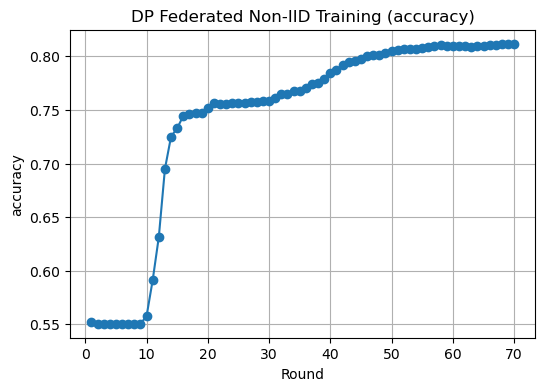

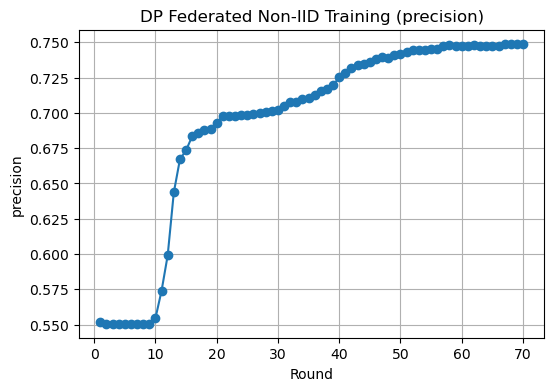

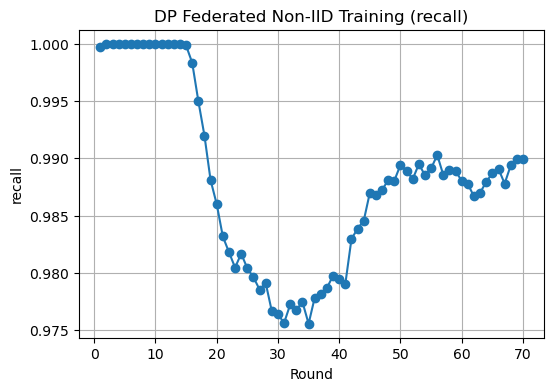

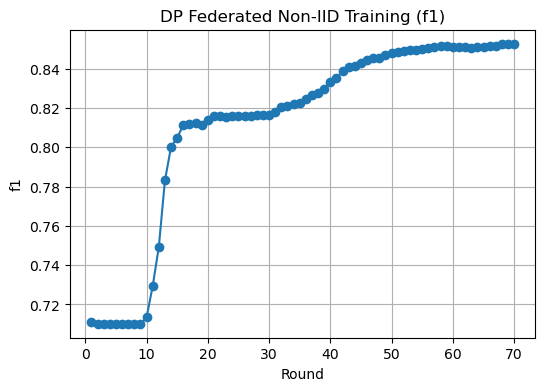

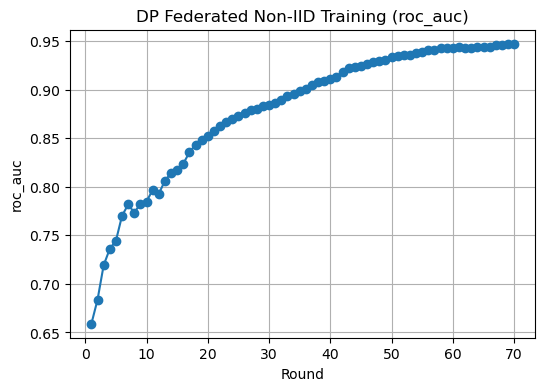

In [29]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
for m in metrics:

    plt.figure(figsize=(6, 4))
    plt.plot(history_df["round"], history_df[m], marker="o")
    plt.title(f"DP Federated Non-IID Training ({m})")
    plt.xlabel("Round")
    plt.ylabel(m)
    plt.grid(True)
    plt.show()

In [30]:
final_results, final_pred, final_prob = evaluate_model(global_model, X_test_tensor, y_test)
import pandas as pd

pd.DataFrame({
    "y_true": y_test,
    "y_prob": final_prob,
    "y_pred": final_pred
}).to_csv("../results/fl_dp_noniid_predictions.csv", index=False)

print("Saved: ../results/fl_dp_noniid_predictions.csv")
print("Final DP Non-IID Results")
print(final_results)

Saved: ../results/fl_dp_noniid_predictions.csv
Final DP Non-IID Results
{'accuracy': 0.8115313608317544, 'precision': 0.7487028911763234, 'recall': 0.9899849995588106, 'f1': 0.8526022816866623, 'roc_auc': np.float64(0.9473365968434685)}


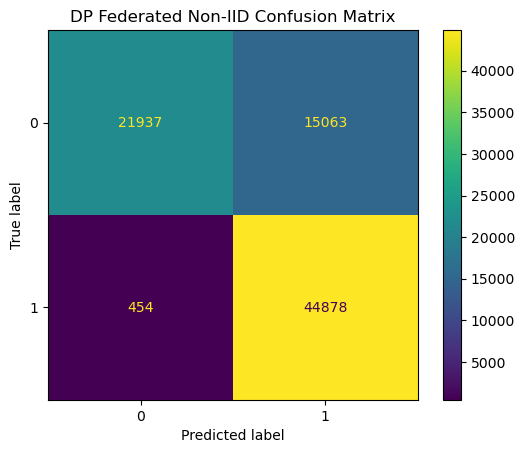

In [31]:
cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("DP Federated Non-IID Confusion Matrix")
plt.show()

In [32]:
os.makedirs("../results", exist_ok=True)

# all rounds
history_df.to_csv("../results/fl_dp_noniid_rounds.csv", index=False)

# final evaluated model metrics
final_df = pd.DataFrame([{
    "model": "FederatedNN_DP_nonIID",
    **final_results
}])
final_df.to_csv("../results/fl_dp_noniid_final.csv", index=False)

print("Saved:")
print(" - ../results/fl_dp_noniid_final.csv")

Saved:
 - ../results/fl_dp_noniid_final.csv
